In [1]:
import pandas as pd
import matplotlib.pyplot as plt
dp003_math = pd.read_csv('dp003_math.csv')
user_data = pd.read_csv('user_data.csv')

95位學生

其中

24位學生有使用dp003

71位學生有使用沒有使用dp003

In [2]:
# Extract unique user_sn from both datasets
dp003_user_sn = set(dp003_math['user_sn'].unique())
user_data_user_sn = set(user_data['user_sn'].unique())

# Identify overlapping and non-overlapping user_sn
common_users = dp003_user_sn.intersection(user_data_user_sn)
only_in_user_data = user_data_user_sn - dp003_user_sn

# Prepare the results as dataframes for easier display and comprehension
common_users_df = pd.DataFrame(common_users, columns=['user_sn'])
only_in_user_data_df = pd.DataFrame(only_in_user_data, columns=['user_sn'])
# Filter user_data to only include users who are in 'Users Only in user_data'
only_in_user_data_math_scores = user_data[user_data['user_sn'].isin(only_in_user_data)][['user_sn', 'math_score']]
only_in_user_data_math_scores['math_score'].describe()

count    71.000000
mean     46.591549
std      15.270492
min      20.000000
25%      36.000000
50%      44.000000
75%      58.000000
max      88.000000
Name: math_score, dtype: float64

In [9]:
# Filter user_data to only include users who are in 'Users Only in user_data'
common_users_math_scores = user_data[user_data['user_sn'].isin(common_users)][['user_sn', 'math_score']]
common_users_math_scores['math_score'].describe()

count    24.000000
mean     47.333333
std      14.381953
min      16.000000
25%      39.000000
50%      46.000000
75%      57.000000
max      72.000000
Name: math_score, dtype: float64

C:\Users\USER\AppData\Local\Temp\ipykernel_35776\2043959119.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


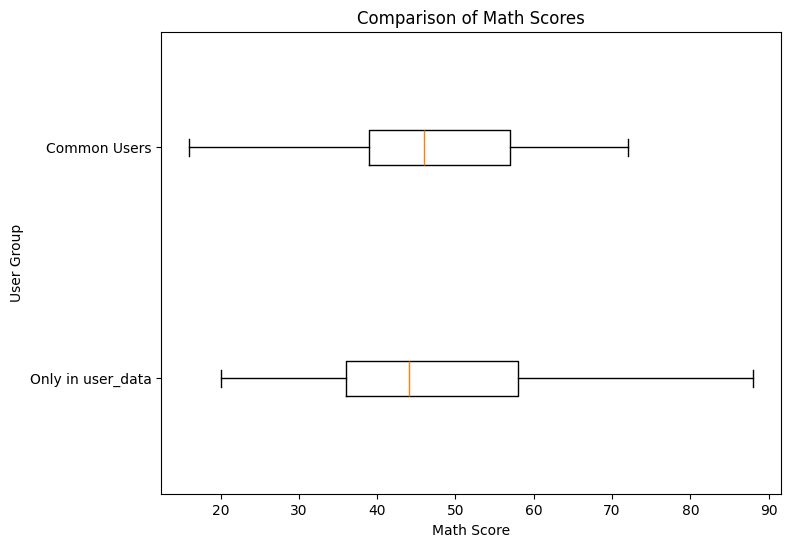

In [10]:
plt.figure(figsize=(8, 6))
plt.boxplot(
    [only_in_user_data_math_scores['math_score'], common_users_math_scores['math_score']],
    labels=['Only in user_data', 'Common Users'],
    vert=False  # Set vert=False for horizontal boxplot
)
plt.title('Comparison of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('User Group')
plt.show()

比較有用dp003和沒有用dp003的學生的數學成績，沒有太大差異，因此做獨立t檢定確認

首先：變異數同質性假定

p-value = 0.7037 > 0.5

接受虛無假設，兩母群變異數相同，進行t檢定

In [11]:
from scipy.stats import levene

# Perform Levene's test for equal variances
levene_stat, levene_p_value = levene(
    only_in_user_data_math_scores['math_score'], 
    common_users_math_scores['math_score']
)

levene_stat, levene_p_value

(0.14555943282142855, 0.7036858521783186)

p-value = 0.8308 > 0.5 不拒絕虛無假設

故兩者母群平均數沒有顯著效果

和有使用dp003和沒有使用dp003的同學，其數學成績沒有太大差異

---

比較只有使用dp001和使用dp001&dp003的數學成績差異

並建立兩者平均數差異的信賴區間

In [12]:
from scipy.stats import ttest_ind

# Null hypothesis: There is no difference between the two groups
# Alternative hypothesis: There is a difference between the two groups

# Perform t-test
t_stat, t_p_value = ttest_ind(
    only_in_user_data_math_scores['math_score'],
    common_users_math_scores['math_score'],
    equal_var=False  # Use Welch's t-test which does not assume equal variances
)

# Display results
# t_stat, t_p_value

# Create a DataFrame to summarize the test results
test_results = pd.DataFrame({
    "Test": ["T-Test"],
    "Statistic": [t_stat],
    "p-value": [t_p_value],
    "Conclusion": [
        "Fail to reject the null hypothesis (No significant difference)",
    ]
})
test_results 

,Test,Statistic,p-value,Conclusion
0,T-Test,-0.215008,0.830805,Fail to reject the null hypothesis (No signifi...


在95%的信心水平下，兩組成績平均數差異的真實值可能落在此範圍內，包含了零，因此無顯著差異